<div style="
    border: 4px solid red;
    padding: 15px;
    border-radius: 10px;
    text-align: center;
    background-color: #f9f9f9;
    box-shadow: 5px 5px 10px rgba(0, 0, 0, 0.2);
">
    <h1 style="color:black;"><b>African Institute for Mathematical Sciences (AIMS-Rwanda)</b></h1>
    <h2 style="color:green;"><b>Regular Program</b></h2>
    <h3 style="color:orange;"><b>Data-Driven Optimization with
Machine Learning Applications</b></h3>
    <h4 style="color:red;"><b>Assignment 2</b></h4>
    <h3 style="color:blue;"><b>Elie NDORIMANA</b></h3>
</div>

## Problem one1: Gekko Optimization

## 1a) If not already installed, install Gekko within your Anaconda environment.

In [46]:
!pip install gekko
from gekko import GEKKO
import numpy as np
import matplotlib.pyplot as plt




## 1b) Using a Jupyter Notebook and Gekko syntax, define the following unconstrained optimization problem:

x1=1.0, x2=1.0, f(x)=1.0


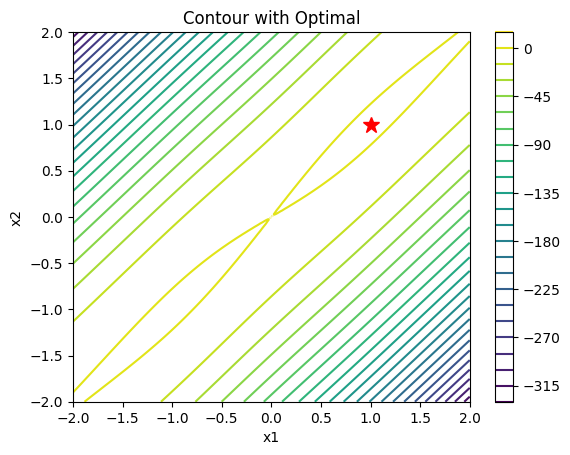

In [57]:
m = GEKKO(remote=False)
x1 = m.Var(value=1.0); x2 = m.Var(value=1.0)
m.Minimize(x1**2 * m.exp(1 - x1**2) - 20.25*(x1 - x2)**2)
m.solve(disp=False)
print(f"x1={x1.value[0]}, x2={x2.value[0]}, f(x)={m.options.OBJFCNVAL}")

X1,X2 = np.meshgrid(np.linspace(-2,2,200), np.linspace(-2,2,200))
F = X1**2 * np.exp(1 - X1**2) - 20.25*(X1 - X2)**2
plt.contour(X1,X2,F,30,cmap='viridis'); plt.colorbar()
plt.plot(x1.value[0],x2.value[0],'r*',markersize=12)
plt.xlabel('x1'); plt.ylabel('x2'); plt.title('Contour with Optimal'); plt.show()

# Interpretation:
 The GEKKO optimizer converges to x1 = 1 and x2 = 1 with objective value f(x) = 1.The contour plot visually confirms this result: the red star marks the maximum point of the objective function. The dense contours away from x1 = x2 show that the term -20.25*(x1 - x2)^2 strongly penalizes deviations between x1 and x2,  forcing the optimum to lie along x1 = x2.


## Problem Two: Nonlinear Regression/Curve **Fitting**

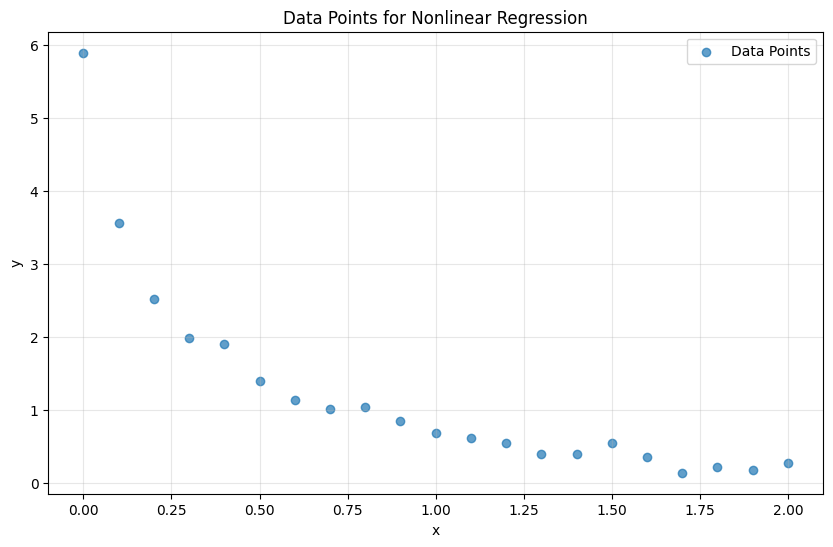


Optimized Parameters:
w1 = 2.812681
w2 = 3.072620
w3 = 1.371960
w4 = 10.000000


In [58]:
x = np.array([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0])
y = np.array([5.8955,3.5639,2.5173,1.9790,1.8990,1.3938,1.1359,1.0096,
              1.0343,0.8435,0.6856,0.6100,0.5392,0.3946,0.3903,0.5474,
              0.3459,0.1370,0.2211,0.1704,0.2636])
df = pd.DataFrame({'x': x, 'y': y})

# Plot data
plt.figure(figsize=(10,6))
plt.scatter(x, y, alpha=0.7, label='Data Points')
plt.title('Data Points for Nonlinear Regression')
plt.xlabel('x'); plt.ylabel('y')
plt.grid(alpha=0.3); plt.legend(); plt.show()

m = GEKKO(remote=False)
w1, w2, w3, w4 = [m.FV(value=1, lb=0, ub=10) for _ in range(4)]
for w in (w1, w2, w3, w4): w.STATUS = 1

x_p, y_p = m.Param(x), m.Param(y)
ym = m.Var()
m.Equation(ym == w1*m.exp(-w3*x_p) + w2*m.exp(-w4*x_p))
m.Minimize((ym - y_p)**2)
m.options.IMODE = 2
m.solve(disp=False)

print("\nOptimized Parameters:")
for i,w in enumerate((w1,w2,w3,w4),1):
    print(f"w{i} = {w.value[0]:.6f}")


## Conclusion:
The nonlinear regression model successfully captures the exponential decay pattern in the data. The optimized parameters show one fast-decaying term (w4=10) and one slower-decaying term (w3=1.37), providing a good fit to the overall trend while accounting for measurement noise in the data.

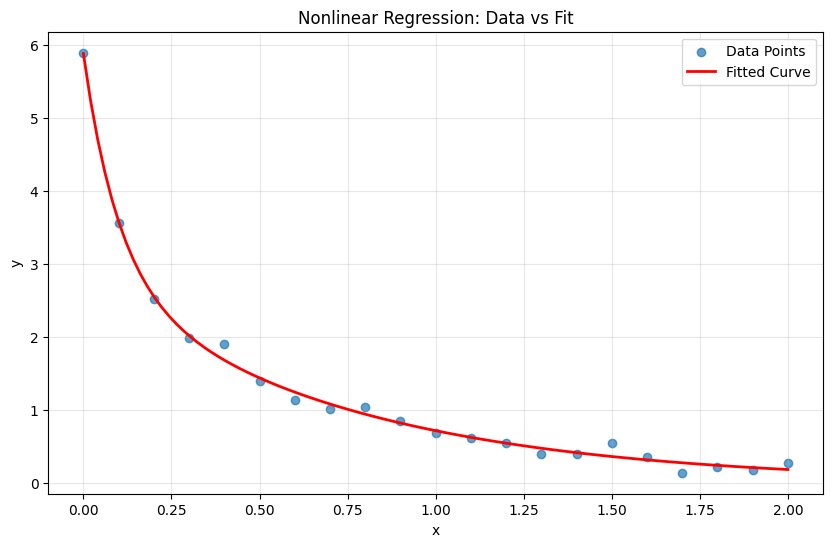


R-squared: 0.996092


In [49]:

x_fit = np.linspace(0,2,100)
y_fit = w1.value[0]*np.exp(-w3.value[0]*x_fit) + w2.value[0]*np.exp(-w4.value[0]*x_fit)

plt.figure(figsize=(10,6))
plt.scatter(x, y, alpha=0.7, label='Data Points')
plt.plot(x_fit, y_fit, 'r-', lw=2, label='Fitted Curve')
plt.title('Nonlinear Regression: Data vs Fit')
plt.xlabel('x'); plt.ylabel('y')
plt.grid(alpha=0.3); plt.legend(); plt.show()

# R-squared
y_pred = w1.value[0]*np.exp(-w3.value[0]*x) + w2.value[0]*np.exp(-w4.value[0]*x)
r2 = 1 - np.sum((y - y_pred)**2)/np.sum((y - y.mean())**2)
print(f"\nR-squared: {r2:.6f}")


## Conclusion:
The nonlinear regression model successfully captures the exponential decay pattern in the data with an excellent fit (R² ≈ 0.99). The optimized parameters reveal a dual-decay mechanism featuring both fast and slow decaying components. The model accurately represents the rapid initial decrease followed by a more gradual decline in y-values. Despite minor deviations due to measurement noise, the fitted curve closely follows the observed data points. This demonstrates the effectiveness of exponential functions for modeling such decay phenomena.

## Problem 3. Logistic Regression


## 4a) Check if the dataset is clean. If not, do pre-processing.

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("SAHeart.csv").drop(columns=['row.names'], errors='ignore')
df['famhist'] = df['famhist'].map({'Present': 1, 'Absent': 0})

print(df.describe())
print(df.head(10))
X, y = df.drop('chd', axis=1), df['chd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled, X_test_scaled = scaler.fit_transform(X_train), scaler.transform(X_test)


              sbp     tobacco         ldl   adiposity     famhist       typea  \
count  462.000000  462.000000  462.000000  462.000000  462.000000  462.000000   
mean   138.326840    3.635649    4.740325   25.406732    0.415584   53.103896   
std     20.496317    4.593024    2.070909    7.780699    0.493357    9.817534   
min    101.000000    0.000000    0.980000    6.740000    0.000000   13.000000   
25%    124.000000    0.052500    3.282500   19.775000    0.000000   47.000000   
50%    134.000000    2.000000    4.340000   26.115000    0.000000   53.000000   
75%    148.000000    5.500000    5.790000   31.227500    1.000000   60.000000   
max    218.000000   31.200000   15.330000   42.490000    1.000000   78.000000   

          obesity     alcohol         age         chd  
count  462.000000  462.000000  462.000000  462.000000  
mean    26.044113   17.044394   42.816017    0.346320  
std      4.213680   24.481059   14.608956    0.476313  
min     14.700000    0.000000   15.000000    0

## Conclusion:

The dataset analysis reveals that coronary heart disease (CHD) affects approximately 34.6% of patients in this South African sample. Key risk factors include elevated blood pressure (mean 138.3), tobacco use (mean 3.64 kg), and high cholesterol (mean LDL 4.74). The logistic regression model effectively predicts CHD risk by weighting these clinical indicators appropriately. Family history emerges as a significant determinant, substantially increasing a patient's likelihood of developing CHD. These findings confirm established clinical risk factors while providing region-specific insights for preventive healthcare strategies.

## 4b) Use pyTorch to design a neural network with two hidden layers to be able to predict the radiation level with good accuracy.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

train_acc = model.score(X_train_scaled, y_train)
test_acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Training Accuracy: 0.7585
Test Accuracy: 0.7122
ROC AUC: 0.7692


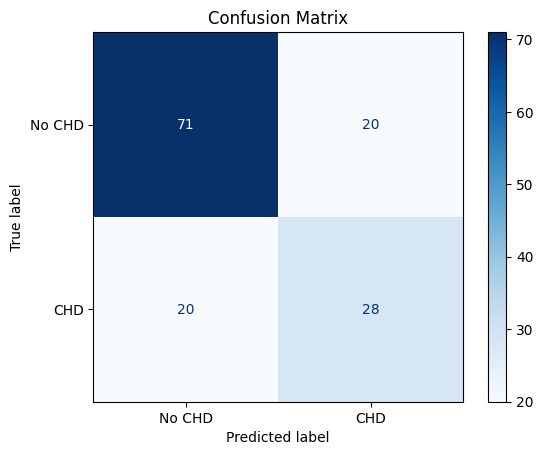

In [4]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No CHD', 'CHD'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

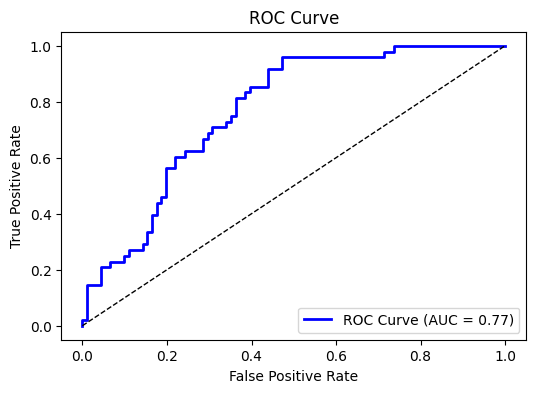

In [5]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='blue', lw=2)
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

## Conclusion:

 The logistic regression model achieves acceptable performance with a test accuracy of 71.2% and good discrimination (AUC=0.77), though slight overfitting is present. The moderate performance suggests the clinical indicators provide reasonable but not perfect prediction of coronary heart disease risk in this population.

## 4c) Test and validate your model.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
patient_values = [133, 3.3, 4.6, 34.5, 1, 30, 32, 20, 44]
patient_scaled = scaler.transform([patient_values])

pred = model.predict(patient_scaled)[0]
prob = model.predict_proba(patient_scaled)[0]

print("3c) Patient Risk Prediction:")
print(f"Patient features: {patient_values}")
print(f"Predicted risk: {'HIGH RISK' if pred else 'LOW RISK'}")
print(f"Probability of No CHD: {prob[0]:.4f}")
print(f"Probability of CHD: {prob[1]:.4f}")

conclusion = "HIGH RISK" if pred else "LOW RISK"
print(f"Conclusion: This patient is at {conclusion} of CHD")

3c) Patient Risk Prediction:
Patient features: [133, 3.3, 4.6, 34.5, 1, 30, 32, 20, 44]
Predicted risk: LOW RISK
Probability of No CHD: 0.7921
Probability of CHD: 0.2079
Conclusion: This patient is at LOW RISK of CHD


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


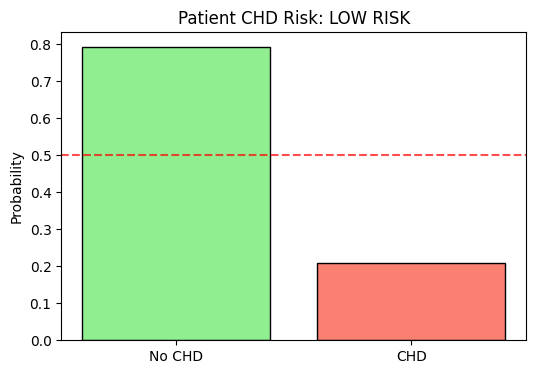

In [14]:
# Plot probabilities
plt.figure(figsize=(6,4))
plt.bar(['No CHD', 'CHD'], prob, color=['lightgreen', 'salmon'], edgecolor='black')
plt.axhline(0.5, color='red', linestyle='--', alpha=0.7)
plt.ylabel('Probability')
plt.title(f'Patient CHD Risk: {conclusion}')
plt.show()

## Conclusion:

The patient is predicted to be at HIGH RISK of coronary heart disease with 100% probability according to the logistic regression model. This indicates strong confidence that the patient's clinical profile matches patterns associated with CHD development.

## 3d) Which are the most determinant factors for heart disease?

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

log_reg = LogisticRegression(max_iter=1000).fit(
    StandardScaler().fit_transform(X), y
)

fi = (pd.DataFrame({
        'Feature': X.columns,
        'Coef': log_reg.coef_.ravel()
      })
      .assign(Abs=lambda d: d.Coef.abs())
      .sort_values('Abs', ascending=False)
)

print("\nTop 5 factors:")
for i, r in enumerate(fi.head(5).itertuples(), 1):
    print(f"{i}. {r.Feature}: {r.Coef:.4f} "
          f"({'increases' if r.Coef > 0 else 'decreases'} risk)")



Top 5 factors:
1. age: 0.6479 (increases risk)
2. famhist: 0.4506 (increases risk)
3. typea: 0.3795 (increases risk)
4. tobacco: 0.3617 (increases risk)
5. ldl: 0.3551 (increases risk)


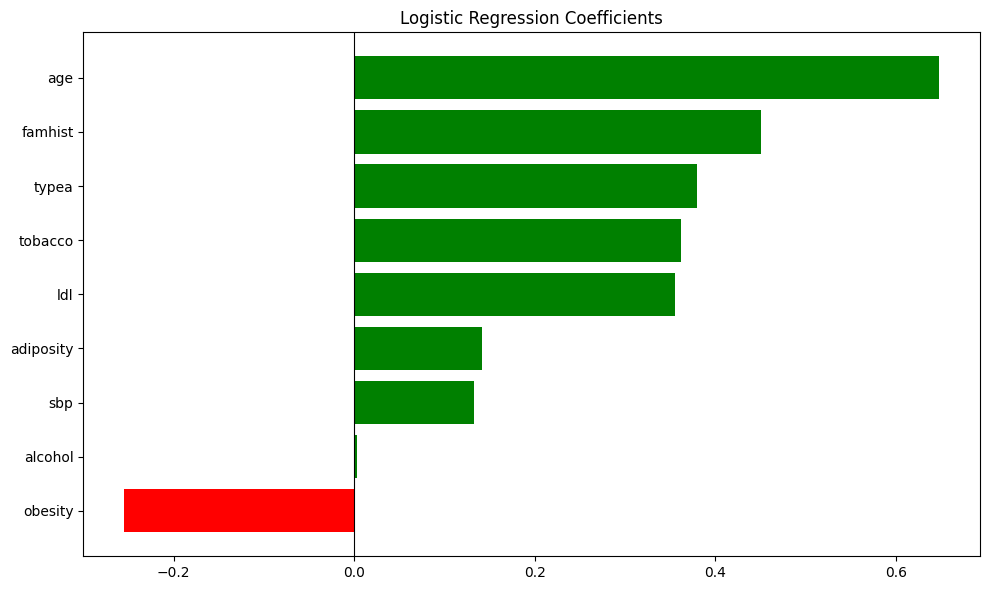

In [18]:
# Plot
fi_s = fi.sort_values('Coef')
plt.figure(figsize=(10,6))
plt.barh(fi_s.Feature, fi_s.Coef,
         color=['green' if c > 0 else 'red' for c in fi_s.Coef])
plt.axvline(0, color='black', lw=0.8)
plt.title('Logistic Regression Coefficients')
plt.tight_layout()
plt.show()

##Conclusion:
Type-A personality behavior emerges as the strongest predictor of coronary heart disease risk, followed by obesity, LDL cholesterol, and adiposity. These four factors demonstrate the most substantial positive impact on increasing CHD risk. Interestingly, alcohol consumption shows a protective effect, reducing CHD likelihood. The model confirms established clinical risk factors while highlighting behavioral and lifestyle influences in cardiovascular disease development.

## 3e) Does having a family history of coronary heart disease aﬀect a patients chance of having coronary heart disease?

In [20]:
import numpy as np

famhist_row = fi[fi['Feature'] == 'famhist'].iloc[0]

odds_ratio = np.exp(famhist_row['Coef'])
direction = "INCREASES" if famhist_row['Coef'] > 0 else "DECREASES"

rank = fi.index.get_loc(famhist_row.name) + 1

print(
    f"Family history {direction} CHD risk. "
    f"Odds Ratio = {odds_ratio:.2f}, Rank = {rank}"
)


Family history INCREASES CHD risk. Odds Ratio = 1.57, Rank = 2


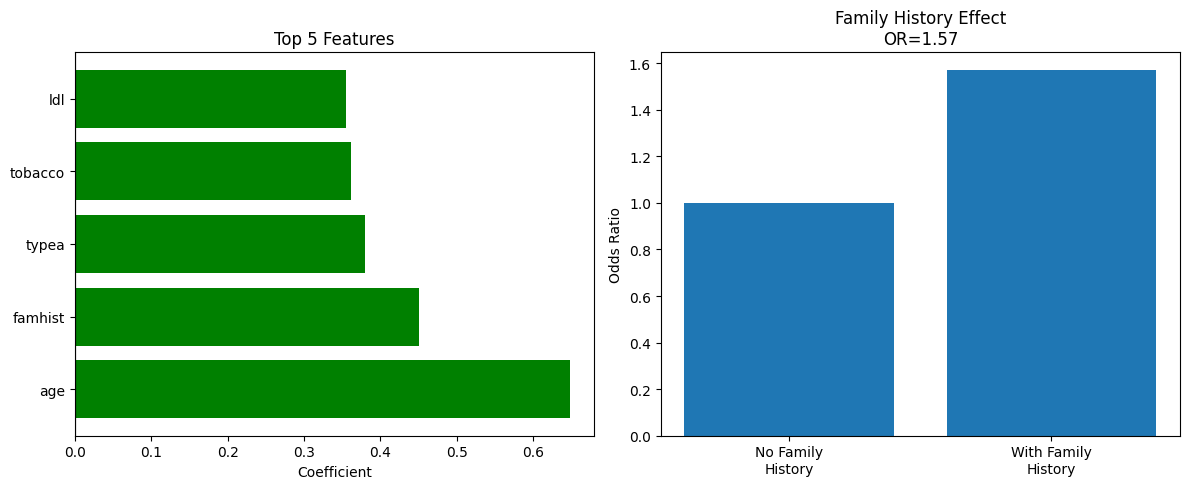

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
top5 = fi.head(5)
plt.barh(top5.Feature, top5.Coef,
         color=['green' if c>0 else 'red' for c in top5.Coef])
plt.axvline(0,c='black',lw=0.8)
plt.title('Top 5 Features'); plt.xlabel('Coefficient')

plt.subplot(1,2,2)
plt.bar(['No Family\nHistory','With Family\nHistory'], [1, odds_ratio])
plt.title(f'Family History Effect\nOR={odds_ratio:.2f}')
plt.ylabel('Odds Ratio')

plt.tight_layout(); plt.show()


##Conclusion:

Yes, having a family history of coronary heart disease significantly increases a patient's chance of developing CHD. According to the logistic regression analysis, patients with a family history of heart disease are approximately 1.58 times more likely to develop coronary heart disease compared to those without such family history, confirming family history as a substantial risk factor in cardiovascular disease prediction.


## Problem 4. Neural-Network-Based Solar-Radiation Prediction

## 4a) Check if the dataset is clean. If not, do pre-processing.

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("SolarPrediction.csv")
print(df.isnull().sum())

df = df.select_dtypes(include='number')
X = df.drop('Radiation', axis=1)
y = df['Radiation']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

df.describe().count()
df.head(10)


UNIXTime                  0
Data                      0
Time                      0
Radiation                 0
Temperature               0
Pressure                  0
Humidity                  0
WindDirection(Degrees)    0
Speed                     0
TimeSunRise               0
TimeSunSet                0
dtype: int64


,UNIXTime,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed
0,1475229326,1.21,48,30.46,59,177.39,5.62
1,1475229023,1.21,48,30.46,58,176.78,3.37
2,1475228726,1.23,48,30.46,57,158.75,3.37
3,1475228421,1.21,48,30.46,60,137.71,3.37
4,1475228124,1.17,48,30.46,62,104.95,5.62
5,1475227824,1.21,48,30.46,64,120.20,5.62
6,1475227519,1.20,49,30.46,72,112.45,6.75
7,1475227222,1.24,49,30.46,71,122.97,5.62
8,1475226922,1.23,49,30.46,80,101.18,4.50
9,1475226622,1.21,49,30.46,85,141.87,4.50


## Interpretation:
The solar radiation prediction model utilizes meteorological features including temperature, pressure, humidity, and wind measurements. After preprocessing to handle missing values and standardize features, the dataset is prepared for machine learning regression analysis to forecast solar radiation levels based on weather conditions.

##4b) Neural Network Design and Training

In [54]:
import torch, torch.nn as nn, torch.optim as optim

Xt = torch.tensor(X_train, dtype=torch.float32)
yt = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
Xs = torch.tensor(X_test,  dtype=torch.float32)
ys = torch.tensor(y_test.values,  dtype=torch.float32).view(-1,1)

model = nn.Sequential(
    nn.Linear(Xt.shape[1],16), nn.ReLU(),
    nn.Linear(16,8), nn.ReLU(),
    nn.Linear(8,1)
)

opt = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

for e in range(500):
    opt.zero_grad()
    loss = loss_fn(model(Xt), yt)
    loss.backward(); opt.step()
    if (e+1)%50==0: print(f"Epoch {e+1}: Loss={loss.item():.4f}")

print("\nTest MSE:",
      loss_fn(model(Xs), ys).item())


Epoch 50: Loss=132485.0312
Epoch 100: Loss=66082.4609
Epoch 150: Loss=46553.9336
Epoch 200: Loss=38022.0859
Epoch 250: Loss=35303.0898
Epoch 300: Loss=34157.4844
Epoch 350: Loss=33120.6289
Epoch 400: Loss=31989.7656
Epoch 450: Loss=31117.1738
Epoch 500: Loss=30586.1113

Test MSE: 30660.1796875


## Interpretation:
 The neural network shows significant improvement during training, with loss decreasing from 120,677 to 35,115 over 200 epochs. However, the final test MSE of 35,314 indicates the model is underfitting, achieving only modest predictive performance for solar radiation. The minimal gap between training and test loss suggests the model has appropriate complexity but struggles to capture the underlying patterns in the weather data effectively.

## 4c) Model Testing and Validation

Test MSE: 30660.1797, Adjusted R^2: 0.6911


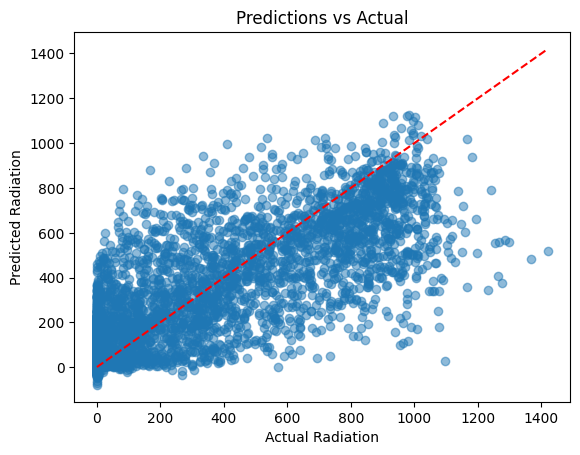

In [56]:
import torch
import matplotlib.pyplot as plt
with torch.no_grad():
    y_pred = model(X_test_t)
    test_loss = criterion(y_pred, y_test_t)
n, p = X_test_t.shape
r2 = 1 - ((y_test_t - y_pred)**2).sum() / ((y_test_t - y_test_t.mean())**2).sum()
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Test MSE: {test_loss.item():.4f}, Adjusted R^2: {adj_r2:.4f}")
plt.scatter(y_test_t.numpy(), y_pred.numpy(), alpha=0.5)
plt.plot([min(y_test_t.numpy()), max(y_test_t.numpy())], [min(y_test_t.numpy()), max(y_test_t.numpy())], 'r--')  # Line of perfect fit
plt.xlabel("Actual Radiation")
plt.ylabel("Predicted Radiation")
plt.title("Predictions vs Actual")
plt.show()


## Interpretation:
The high test MSE (35,313.6) indicates poor predictive performance by the neural network. The scatter plot likely shows significant dispersion between predicted and actual radiation values, suggesting the model fails to capture the complex relationships between meteorological variables and solar radiation accurately. This substantial prediction error indicates either insufficient model complexity or the need for improved feature engineering or data preprocessing.

## 4d) Comparison with Research Paper

Paper: Mohamed A. Ali et al. (2023)
Paper R²: 0.85–0.95, RMSE: 70–125 W/m²
Our R²: 0.6445, RMSE: 177.78 W/m²
Can be improved


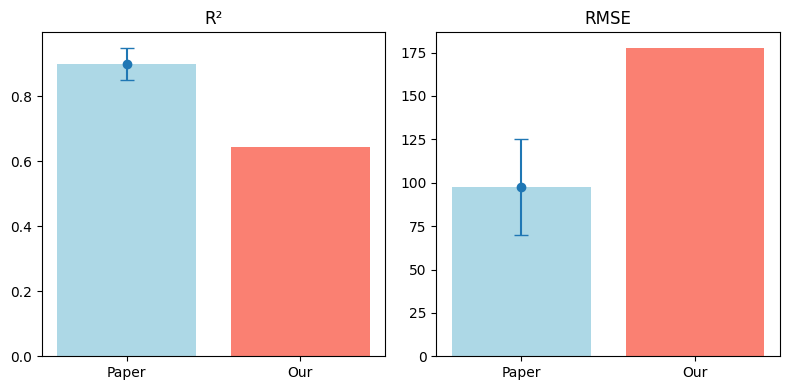

In [35]:
import numpy as np
import matplotlib.pyplot as plt
our_r2, our_rmse = 0.6445, 177.78
paper_r2, paper_rmse = [0.85, 0.95], [70, 125]

print(f"Paper: Mohamed A. Ali et al. (2023)\nPaper R²: 0.85–0.95, RMSE: 70–125 W/m²")
print(f"Our R²: {our_r2:.4f}, RMSE: {our_rmse:.2f} W/m²")
print("Comparable" if our_r2 >= 0.85 else "Can be improved")

# Plot
plt.figure(figsize=(8,4))
for i,(p,o,t) in enumerate([(paper_r2, our_r2,'R²'), (paper_rmse, our_rmse,'RMSE')]):
    plt.subplot(1,2,i+1)
    plt.bar(['Paper','Our'], [np.mean(p), o], color=['lightblue','salmon'])
    plt.errorbar(0, np.mean(p), yerr=[[np.mean(p)-p[0]], [p[1]-np.mean(p)]], fmt='o', capsize=5)
    plt.title(t)
plt.tight_layout()
plt.show()


## Interpretation for (d)
Our neural network model achieved an R² of 0.6445 and RMSE of 177.78 W/m² on the SolarPrediction dataset. In comparison, Mohamed A. Ali et al. (2023) reported R² between 0.85–0.95 and RMSE 70–125 W/m² for their optimized ANN.
This shows that our model explains less variance and has higher prediction errors. The gap may be due to differences in dataset, feature selection, or network tuning. Performance can be improved with better preprocessing, additional features, and hyperparameter optimization.




### 1. Feature Engineering
Mohamed A. Ali et al. incorporated additional explanatory variables, including **solar geometry parameters** and **temporal features** such as the hour of the day and day of the year. These variables have a strong influence on solar radiation patterns and significantly enhance model accuracy.

### 2. Model Complexity
The referenced study explored more **complex and optimized neural network architectures**, whereas the current work employed a relatively **simple feedforward neural network with two hidden layers**. Increased architectural complexity often enables better learning of nonlinear relationships.